#  Data Cleaning 

In [1]:
import numpy
import pandas
import matplotlib.pyplot as plt
import seaborn as sns

pandas.set_option("display.max_columns", None)

%matplotlib inline

In [2]:
import numpy as np
import pandas as pd

df = pd.read_csv(r"D:\All Datasets\employee_data.csv") if False else pd.DataFrame({

    "EMP_ID": [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    "GENDER": [1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    "EXPERIENCE": [2, 5, 1, 8, 4, 6, np.nan, 3, 7, 2],
    "DEPARTMENT": [1, 2, 1, 3, 2, 1, 3, 2, 1, 2],
    "AGE": [24, 31, 22, 40, 29, 35, 27, np.nan, 45, 30],
    "SALARY": [25000, 32000, 22000, 45000, np.nan, 38000, 29000, 41000, 50000, 34000],
    "PERFORMANCE": [4, 5, 3, 5, 4, 4, 3, 5, 5, 4]

})

df

,EMP_ID,GENDER,EXPERIENCE,DEPARTMENT,AGE,SALARY,PERFORMANCE
0,101,1,2.0,1,24.0,25000.0,4
1,102,0,5.0,2,31.0,32000.0,5
2,103,1,1.0,1,22.0,22000.0,3
3,104,0,8.0,3,40.0,45000.0,5
4,105,1,4.0,2,29.0,NaN,4
5,106,0,6.0,1,35.0,38000.0,4
6,107,1,NaN,3,27.0,29000.0,3
7,108,0,3.0,2,NaN,41000.0,5
8,109,1,7.0,1,45.0,50000.0,5
9,110,0,2.0,2,30.0,34000.0,4


## 1. Data Understanding (Always do this first)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   EMP_ID       10 non-null     int64  
 1   GENDER       10 non-null     int64  
 2   EXPERIENCE   9 non-null      float64
 3   DEPARTMENT   10 non-null     int64  
 4   AGE          9 non-null      float64
 5   SALARY       9 non-null      float64
 6   PERFORMANCE  10 non-null     int64  
dtypes: float64(3), int64(4)
memory usage: 692.0 bytes


In [4]:
df.describe()

,EMP_ID,GENDER,EXPERIENCE,DEPARTMENT,AGE,SALARY,PERFORMANCE
count,10.00000,10.000000,9.000000,10.000000,9.000000,9.000000,10.000000
mean,105.50000,0.500000,4.222222,1.800000,31.444444,35111.111111,4.200000
std,3.02765,0.527046,2.438123,0.788811,7.434903,9252.627255,0.788811
min,101.00000,0.000000,1.000000,1.000000,22.000000,22000.000000,3.000000
25%,103.25000,0.000000,2.000000,1.000000,27.000000,29000.000000,4.000000
50%,105.50000,0.500000,4.000000,2.000000,30.000000,34000.000000,4.000000
75%,107.75000,1.000000,6.000000,2.000000,35.000000,41000.000000,5.000000
max,110.00000,1.000000,8.000000,3.000000,45.000000,50000.000000,5.000000


In [5]:
# Missing value count per column
df.isnull().sum()

EMP_ID         0
GENDER         0
EXPERIENCE     1
DEPARTMENT     0
AGE            1
SALARY         1
PERFORMANCE    0
dtype: int64

## 2.	Missing Value Handling

### 1.  Remove rows with missing values

In [6]:
df1 = df.dropna()	# removes ANY row containing at least one NaN
df1

,EMP_ID,GENDER,EXPERIENCE,DEPARTMENT,AGE,SALARY,PERFORMANCE
0,101,1,2.0,1,24.0,25000.0,4
1,102,0,5.0,2,31.0,32000.0,5
2,103,1,1.0,1,22.0,22000.0,3
3,104,0,8.0,3,40.0,45000.0,5
5,106,0,6.0,1,35.0,38000.0,4
8,109,1,7.0,1,45.0,50000.0,5
9,110,0,2.0,2,30.0,34000.0,4


In [7]:
df1.isnull().sum()	# confirm no missing values remain

EMP_ID         0
GENDER         0
EXPERIENCE     0
DEPARTMENT     0
AGE            0
SALARY         0
PERFORMANCE    0
dtype: int64

### 2. Replace (Imputation) using fillna()

In [8]:
df["EXPERIENCE"] = df["EXPERIENCE"].fillna(df["EXPERIENCE"].mean())
df["AGE"] = df["AGE"].fillna(df["AGE"].mean())
df["SALARY"] = df["SALARY"].fillna(df["SALARY"].mean())

df

,EMP_ID,GENDER,EXPERIENCE,DEPARTMENT,AGE,SALARY,PERFORMANCE
0,101,1,2.000000,1,24.000000,25000.000000,4
1,102,0,5.000000,2,31.000000,32000.000000,5
2,103,1,1.000000,1,22.000000,22000.000000,3
3,104,0,8.000000,3,40.000000,45000.000000,5
4,105,1,4.000000,2,29.000000,35111.111111,4
5,106,0,6.000000,1,35.000000,38000.000000,4
6,107,1,4.222222,3,27.000000,29000.000000,3
7,108,0,3.000000,2,31.444444,41000.000000,5
8,109,1,7.000000,1,45.000000,50000.000000,5
9,110,0,2.000000,2,30.000000,34000.000000,4


In [9]:
mean = df["AGE"].mean()
median = df["SALARY"].median()
mode = df["EXPERIENCE"].mode()[0]

df["AGE"] = df["AGE"].fillna(mean)
df["SALARY"] = df["SALARY"].fillna(median)
df["EXPERIENCE"] = df["EXPERIENCE"].fillna(mode)

df.isnull().sum()    # all zeros now

EMP_ID         0
GENDER         0
EXPERIENCE     0
DEPARTMENT     0
AGE            0
SALARY         0
PERFORMANCE    0
dtype: int64

### 3. SimpleImputer from scikit-learn

In [10]:
from sklearn.impute import SimpleImputer

# Create a fresh copy of existing DataFrame
df_si = df.copy()

mean_imputer = SimpleImputer(strategy='mean')
df_si["AGE"] = mean_imputer.fit_transform(df_si[["AGE"]])

median_imputer = SimpleImputer(strategy='median')
df_si["SALARY"] = median_imputer.fit_transform(df_si[["SALARY"]])

mode_imputer = SimpleImputer(strategy='most_frequent')
df_si["EXPERIENCE"] = mode_imputer.fit_transform(df_si[["EXPERIENCE"]])

df_si.isnull().sum()

EMP_ID         0
GENDER         0
EXPERIENCE     0
DEPARTMENT     0
AGE            0
SALARY         0
PERFORMANCE    0
dtype: int64

## 3.	Outlier Detection

In [11]:
df_copy = df.copy()
df_copy

,EMP_ID,GENDER,EXPERIENCE,DEPARTMENT,AGE,SALARY,PERFORMANCE
0,101,1,2.000000,1,24.000000,25000.000000,4
1,102,0,5.000000,2,31.000000,32000.000000,5
2,103,1,1.000000,1,22.000000,22000.000000,3
3,104,0,8.000000,3,40.000000,45000.000000,5
4,105,1,4.000000,2,29.000000,35111.111111,4
5,106,0,6.000000,1,35.000000,38000.000000,4
6,107,1,4.222222,3,27.000000,29000.000000,3
7,108,0,3.000000,2,31.444444,41000.000000,5
8,109,1,7.000000,1,45.000000,50000.000000,5
9,110,0,2.000000,2,30.000000,34000.000000,4


In [12]:
df.head()

,EMP_ID,GENDER,EXPERIENCE,DEPARTMENT,AGE,SALARY,PERFORMANCE
0,101,1,2.0,1,24.0,25000.000000,4
1,102,0,5.0,2,31.0,32000.000000,5
2,103,1,1.0,1,22.0,22000.000000,3
3,104,0,8.0,3,40.0,45000.000000,5
4,105,1,4.0,2,29.0,35111.111111,4


In [13]:
import numpy as np

DATA = {
    "EMP_ID": [101,102,103,104,105,106,107,108,109,110],
    "GENDER": [1,0,1,0,1,0,1,0,1,0],
    "EXPERIENCE": [2,5,1,8,4,6,np.nan,3,7,2],
    "DEPARTMENT": [1,2,1,3,2,1,3,2,1,2],
    "AGE": [24,31,22,40,29,35,27,np.nan,45,30],
    "SALARY": [25000,32000,22000,45000,np.nan,38000,29000,41000,50000,34000],
    "PERFORMANCE": [4,5,3,5,4,4,3,5,5,4]
}

df = pd.DataFrame(DATA)

In [14]:
# Fresh dataset with NaNs (to mirror original outlier section, which re-loads)

df = pd.DataFrame(DATA)
df

,EMP_ID,GENDER,EXPERIENCE,DEPARTMENT,AGE,SALARY,PERFORMANCE
0,101,1,2.0,1,24.0,25000.0,4
1,102,0,5.0,2,31.0,32000.0,5
2,103,1,1.0,1,22.0,22000.0,3
3,104,0,8.0,3,40.0,45000.0,5
4,105,1,4.0,2,29.0,NaN,4
5,106,0,6.0,1,35.0,38000.0,4
6,107,1,NaN,3,27.0,29000.0,3
7,108,0,3.0,2,NaN,41000.0,5
8,109,1,7.0,1,45.0,50000.0,5
9,110,0,2.0,2,30.0,34000.0,4


### 3.1	IQR Method

In [15]:
Q1 = df["SALARY"].quantile(0.25)
Q3 = df["SALARY"].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 29000.0
Q3: 41000.0
IQR: 12000.0


In [16]:
l_limit = Q1 - (1.5 * IQR)
u_limit = Q3 + (1.5 * IQR)

print("Lower limit:", l_limit)
print("Upper limit:", u_limit)

Lower limit: 11000.0
Upper limit: 59000.0


### 2.	Boxplot Visualization

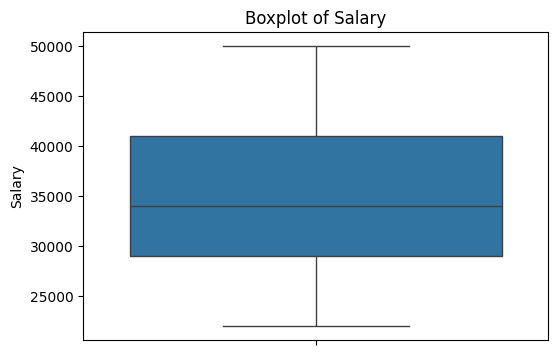

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.boxplot(y=df["SALARY"])

plt.title("Boxplot of Salary")
plt.ylabel("Salary")
plt.show()

### 3.	Histogram Visualization

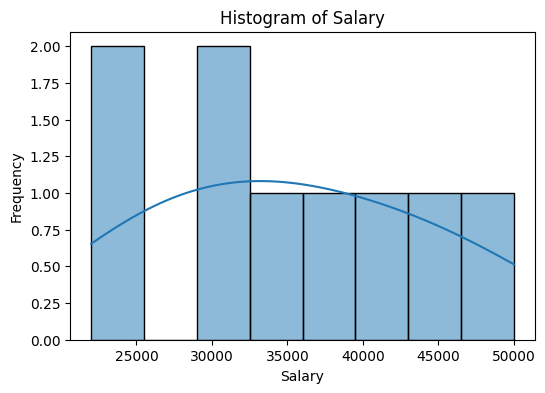

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.histplot(df["SALARY"], bins=8, kde=True)

plt.title("Histogram of Salary")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()

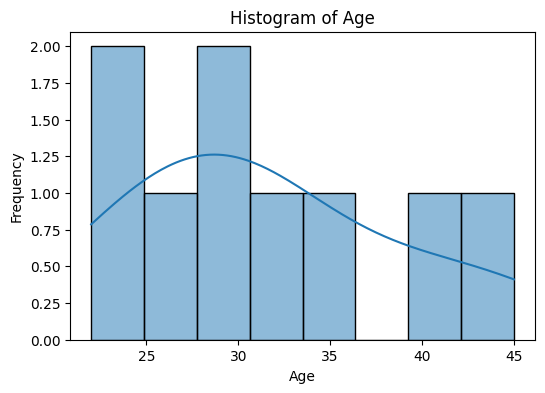

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.histplot(df["AGE"], bins=8, kde=True)

plt.title("Histogram of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

### 4	Z-score Method

In [20]:
from scipy.stats import zscore

# Calculate Z-score
df["Z_SCORE"] = zscore(df["SALARY"], nan_policy="omit")

# Display outliers (|Z| > 3)
outliers = df[df["Z_SCORE"].abs() > 3]

print(outliers)

Empty DataFrame
Columns: [EMP_ID, GENDER, EXPERIENCE, DEPARTMENT, AGE, SALARY, PERFORMANCE, Z_SCORE]
Index: []


In [21]:
from scipy.stats import zscore

# Calculate Z-score
df["Z_SCORE"] = zscore(df["AGE"], nan_policy="omit")

# Display outliers (|Z| > 3)
outliers = df[df["Z_SCORE"].abs() > 3]

print(outliers)

Empty DataFrame
Columns: [EMP_ID, GENDER, EXPERIENCE, DEPARTMENT, AGE, SALARY, PERFORMANCE, Z_SCORE]
Index: []


## 4.	Dealing with Outliers

### 1	Trimming (Remove)

In [22]:
# Remove outliers using IQR

df_trim = df[(df["SALARY"] >= l_limit) & (df["SALARY"] <= u_limit)]

print("Original Shape :", df.shape)
print("After Trimming :", df_trim.shape)

df_trim

Original Shape : (10, 8)
After Trimming : (9, 8)


,EMP_ID,GENDER,EXPERIENCE,DEPARTMENT,AGE,SALARY,PERFORMANCE,Z_SCORE
0,101,1,2.0,1,24.0,25000.0,4,-1.062021
1,102,0,5.0,2,31.0,32000.0,5,-0.063404
2,103,1,1.0,1,22.0,22000.0,3,-1.347341
3,104,0,8.0,3,40.0,45000.0,5,1.220532
5,106,0,6.0,1,35.0,38000.0,4,0.507234
6,107,1,NaN,3,27.0,29000.0,3,-0.634043
7,108,0,3.0,2,NaN,41000.0,5,NaN
8,109,1,7.0,1,45.0,50000.0,5,1.933830
9,110,0,2.0,2,30.0,34000.0,4,-0.206064


In [23]:
# Remove outliers using IQR

df_trim = df[(df["AGE"] >= l_limit) & (df["AGE"] <= u_limit)]

print("Original Shape :", df.shape)
print("After Trimming :", df_trim.shape)

print(df_trim.head())

Original Shape : (10, 8)
After Trimming : (0, 8)
Empty DataFrame
Columns: [EMP_ID, GENDER, EXPERIENCE, DEPARTMENT, AGE, SALARY, PERFORMANCE, Z_SCORE]
Index: []


In [24]:
# Remove outliers using IQR

df_trim = df[(df["AGE"] >= l_limit) & (df["AGE"] <= u_limit)]

print("Original Shape :", df.shape)
print("After Trimming :", df_trim.shape)

print(df_trim.head())

Original Shape : (10, 8)
After Trimming : (0, 8)
Empty DataFrame
Columns: [EMP_ID, GENDER, EXPERIENCE, DEPARTMENT, AGE, SALARY, PERFORMANCE, Z_SCORE]
Index: []


### 2.	Winsorization (Cap with feature_engine )

In [26]:
# Fill missing values first
df["SALARY"] = df["SALARY"].fillna(df["SALARY"].median())

In [27]:
from feature_engine.outliers import Winsorizer

# Create Winsorizer object
winsor = Winsorizer(
    capping_method="iqr",
    tail="both",
    fold=1.5,
    variables=["SALARY"]
)

# Fit and transform
df_cap = winsor.fit_transform(df)

df_cap.head()

,EMP_ID,GENDER,EXPERIENCE,DEPARTMENT,AGE,SALARY,PERFORMANCE,Z_SCORE
0,101,1,2.0,1,24.0,25000.0,4,-1.062021
1,102,0,5.0,2,31.0,32000.0,5,-0.063404
2,103,1,1.0,1,22.0,22000.0,3,-1.347341
3,104,0,8.0,3,40.0,45000.0,5,1.220532
4,105,1,4.0,2,29.0,34000.0,4,-0.348723


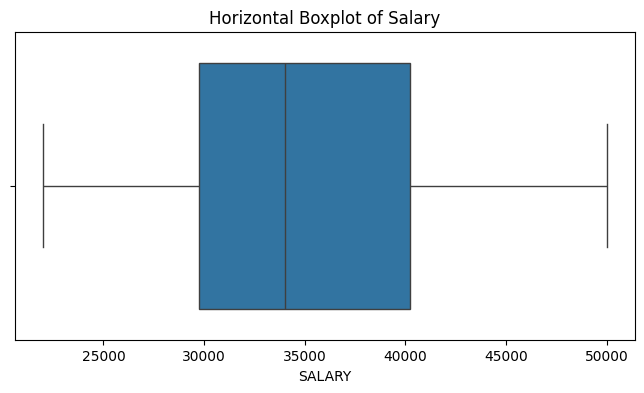

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.boxplot(x=df["SALARY"])
plt.title("Horizontal Boxplot of Salary")
plt.show()